In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
files = {
    "areas1": "data/areas1.txt",
    "abs_errors1": "data/abs_errors1.txt",
    "rel_errors1": "data/rel_errors1.txt",
    "areas2": "data/areas2.txt",
    "abs_errors2": "data/abs_errors2.txt",
    "rel_errors2": "data/rel_errors2.txt",
}

ITERATION_START = 100
ITERATION_STOP = 100000
ITERATION_STEP = 500

REAL_AREA = 0.25 * np.pi + 1.25 * np.arcsin(0.8) - 1.0


In [3]:
def load_data_from_file(filename):
    try:
        with open(filename, "r") as f:
            data = np.array([float(line.strip()) for line in f])
        return data
    except FileNotFoundError:
        print(f"Файл '{filename}' не найден.")
        return None
    except ValueError:
        print(f"Файл '{filename}' содержит некорректные данные (не числа).")
        return None


In [4]:
def plot_convergence(iteration_counts, areas1, areas2):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(12, 7))

    plt.plot(iteration_counts, areas1, marker="o", markersize=4, linestyle="-", label="Метод 1: Большой прямоугольник")

    plt.plot(iteration_counts, areas2, marker="x", markersize=5, linestyle="-", label="Метод 2: Минимальный квадрат")

    plt.axhline(y=REAL_AREA, color="r", linestyle="--", linewidth=2, label=f"Точная площадь ≈ {REAL_AREA:.6f}")

    plt.title("Сходимость оценки площади методом Монте-Карло", fontsize=16)
    plt.xlabel("Количество итераций", fontsize=12)
    plt.ylabel("Приближенное значение площади", fontsize=12)
    plt.legend(fontsize=11)
    plt.ticklabel_format(style="plain", axis="x")

    plt.tight_layout()
    plt.savefig("convergence_plot.png", dpi=300)
    plt.show()


def plot_relative_error(iteration_counts, rel_errors1, rel_errors2):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(12, 7))

    plt.plot(iteration_counts, rel_errors1, marker="o", markersize=4, linestyle="-", label="Метод 1: Большой прямоугольник")

    plt.plot(iteration_counts, rel_errors2, marker="x", markersize=5, linestyle="-", label="Метод 2: Минимальный квадрат")

    plt.title("Зависимость относительной погрешности от числа итераций", fontsize=16)
    plt.xlabel("Количество итераций", fontsize=12)
    plt.ylabel("Относительная погрешность (log шкала)", fontsize=12)

    plt.yscale("log")

    plt.legend(fontsize=11)
    plt.ticklabel_format(style="plain", axis="x")

    plt.tight_layout()
    plt.savefig("relative_error_plot.png", dpi=300)
    plt.show()


def plot_absolute_error(iteration_counts, abs_errors1, abs_errors2):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(12, 7))

    plt.plot(iteration_counts, abs_errors1, marker="o", markersize=4, linestyle="-", label="Метод 1: Большой прямоугольник")

    plt.plot(iteration_counts, abs_errors2, marker="x", markersize=5, linestyle="-", label="Метод 2: Минимальный квадрат")

    plt.title("Зависимость абсолютной погрешности от числа итераций", fontsize=16)
    plt.xlabel("Количество итераций", fontsize=12)
    plt.ylabel("Абсолютная погрешность (log шкала)", fontsize=12)

    plt.yscale("log")

    plt.legend(fontsize=11)
    plt.ticklabel_format(style="plain", axis="x")

    plt.tight_layout()
    plt.savefig("absolute_error_plot.png", dpi=300)
    plt.show()


In [5]:
def main():
    data = {}
    all_files_loaded = True
    for key, filename in files.items():
        loaded_data = load_data_from_file(filename)
        if loaded_data is None:
            all_files_loaded = False
            break
        data[key] = loaded_data

    if not all_files_loaded:
        print("\nАнализ прерван из-за ошибки чтения файлов.")
        return

    print("Все файлы успешно загружены.")

    iteration_counts = np.arange(ITERATION_START, ITERATION_STOP, ITERATION_STEP)

    if len(data["areas1"]) != len(iteration_counts):
        print("\n Количество точек в данных не совпадает с ожидаемым количеством итераций.")
        print(f" Ожидалось {len(iteration_counts)} точек, в файле {len(data['areas1'])}.")
        return

    plot_convergence(iteration_counts, data["areas1"], data["areas2"])

    plot_relative_error(iteration_counts, data["rel_errors1"], data["rel_errors2"])

    plot_absolute_error(iteration_counts, data["abs_errors1"], data["abs_errors2"])
    print("Графики сохранены в файлы 'convergence_plot.png', 'absolute_error_plot.png' и 'relative_error_plot.png'")


Все файлы успешно загружены.


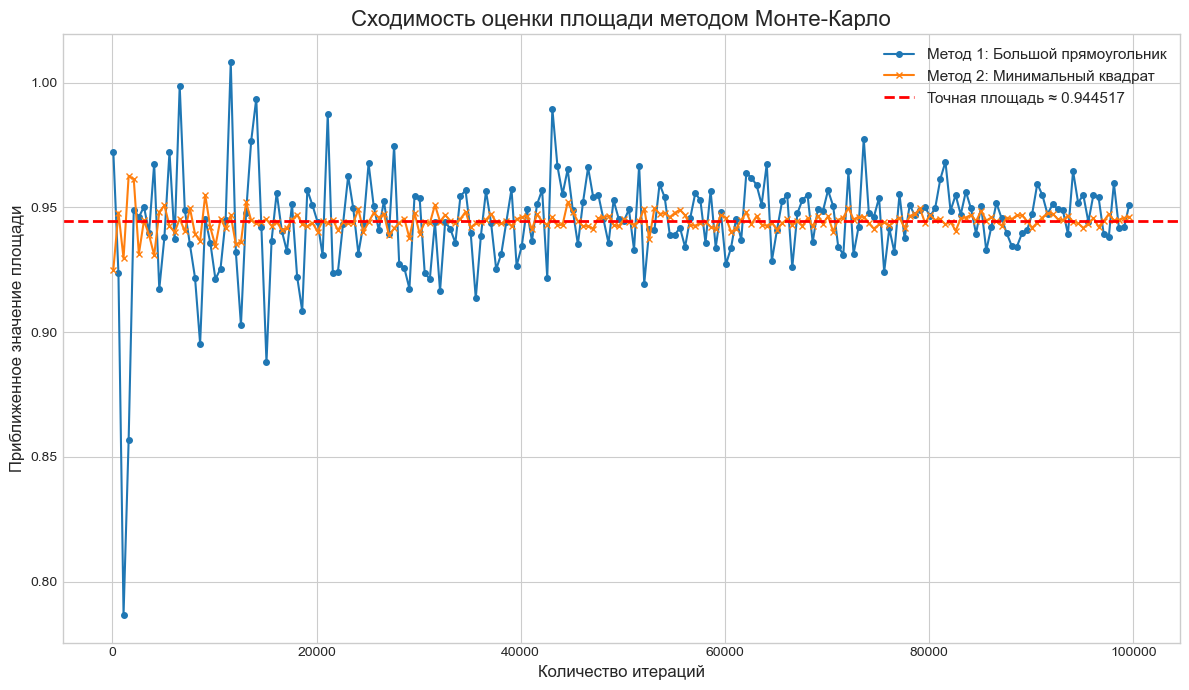

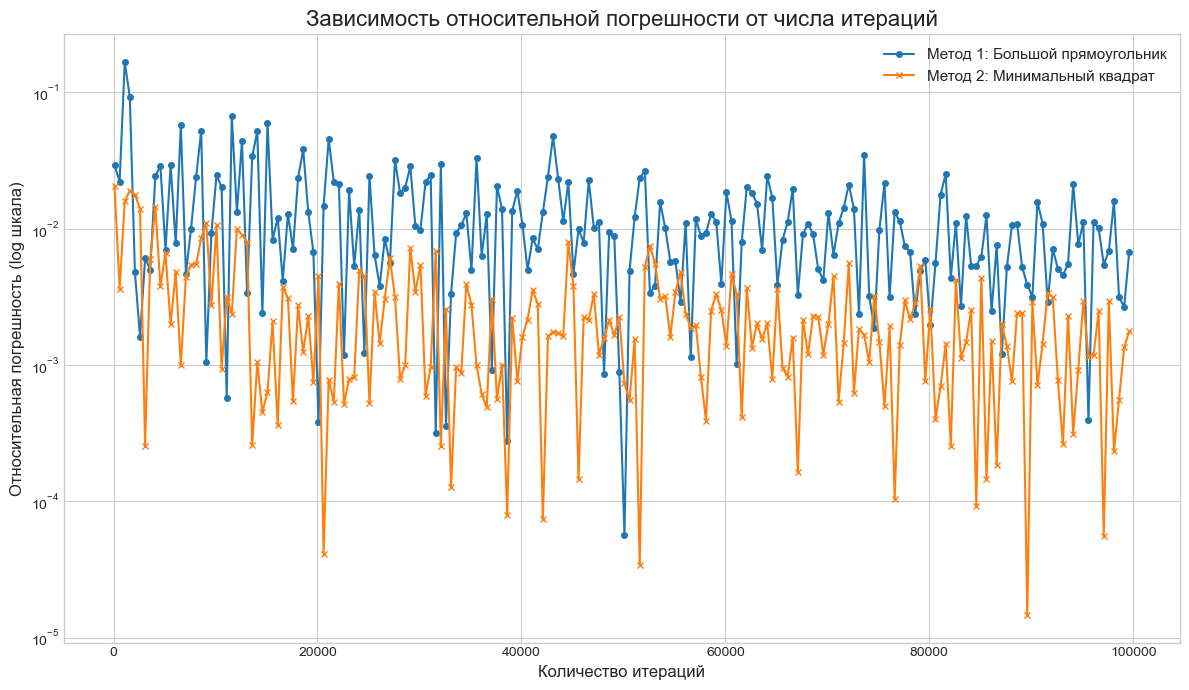

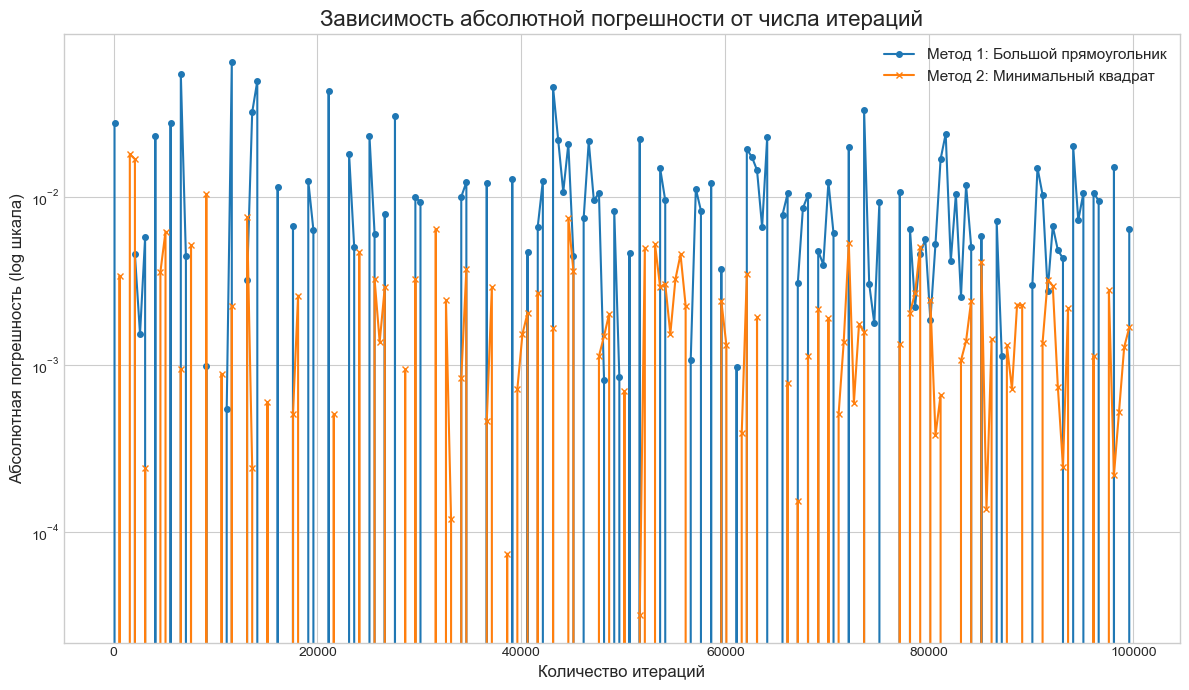

Графики сохранены в файлы 'convergence_plot.png', 'absolute_error_plot.png' и 'relative_error_plot.png'


In [6]:
main()